<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week6_Day1_Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs

Large Language Models (LLMs) are deep learning algorithms trained on massive datasets of text (and sometimes other media) to understand, summarize, generate, and predict new content. They are primarily designed to solve Natural Language Processing (NLP) tasks such as translation, sentiment analysis, text summarization, and creative content generation by predicting the next token in a sequence based on probability distributions.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 120.8 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'  # TODO: choose a causal LM checkpoint, e.g., 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)   # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


Tokenization is the process of breaking down a string of text into smaller units called tokens (words, subwords, or characters). These tokens are then converted into numerical identifiers (IDs) that the transformer model can process mathematically.

Original Text: Artificial intelligence is changing the world.
Tokens: ['Art', 'ificial', 'Ġintelligence', 'Ġis', 'Ġchanging', 'Ġthe', 'Ġworld', '.']
Token IDs: [8001, 9542, 4430, 318, 5609, 262, 995, 13]


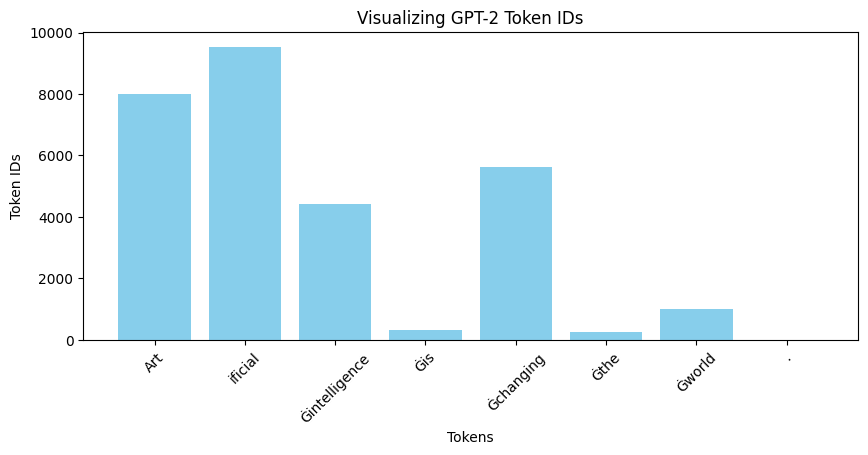

In [ ]:
text = "Artificial intelligence is changing the world."  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Visualizing GPT-2 Token IDs"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [ ]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
for token, tid in zip(tokens, token_ids):
    print(f"Token: {token:<15} | ID: {tid}")

Token: Art             | ID: 8001
Token: ificial         | ID: 9542
Token: Ġintelligence   | ID: 4430
Token: Ġis             | ID: 318
Token: Ġchanging       | ID: 5609
Token: Ġthe            | ID: 262
Token: Ġworld          | ID: 995
Token: .               | ID: 13


In GPT-style vocabularies (like Byte-Pair Encoding), the `Ġ` character represents a **leading space**. It indicates that the token starts a new word rather than being a continuation of a previous word fragment.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [ ]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The future of technology is"  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: The future of technology is
Generated Output: The future of technology is a very uncertain one, and it's likely we'll find ourselves on a path to become far more advanced than ever before.

It's a good time to start thinking about what will happen to this year's tech industry in the next few years.


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)